<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/projects/project_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Analítica de Recursos Humanos: Determinantes Salariales y Modelación de Compensaciones


## Contexto y Objetivo

Una firma multinacional de consultoría ha sido contratada por **TalentCo**, empresa con operaciones en múltiples regiones y departamentos, para analizar su estructura de compensaciones. El equipo de Recursos Humanos sospecha que los salarios no están siendo asignados de manera consistente: algunos empleados se sienten subpagados en relación con pares de experiencia similar, mientras que otros en el mismo departamento perciben montos significativamente distintos según su región o nivel educacional.

Su rol es actuar como **Analista de Datos** en la firma consultora. Utilizará Python, pruebas de hipótesis estadísticas y regresión lineal para identificar los principales determinantes del salario de los empleados, y entregará recomendaciones basadas en datos a la dirección de TalentCo.

Al finalizar este proyecto, usted será capaz de:

- Realizar análisis exploratorio de datos (EDA) sobre datos de Recursos Humanos.
- Aplicar pruebas de hipótesis para validar supuestos de negocio.
- Manejar variables categóricas mediante técnicas de codificación.
- Construir y evaluar modelos de regresión con OLS y scikit-learn.
- Verificar los supuestos de regresión (multicolinealidad, normalidad, homocedasticidad).
- Comunicar resultados en un informe orientado al negocio.



## Conjunto de Datos: `employee_compensation.csv`

Disponible en la sección de materiales del curso. Contiene registros de **1.500 empleados** distribuidos en distintos departamentos, regiones y niveles de cargo.

| Variable | Tipo | Descripción |
|---|---|---|
| `Salary` | Numérica (USD/año) | Salario bruto anual — **variable objetivo** |
| `Years_Experience` | Numérica | Total de años de experiencia profesional |
| `Age` | Numérica | Edad del empleado |
| `Performance_Score` | Numérica (1.0–5.0) | Calificación de desempeño anual más reciente |
| `Education_Level` | Categórica | Bachelor, Master, PhD |
| `Department` | Categórica | Engineering, Sales, Marketing, HR, Finance |
| `Region` | Categórica | North, South, East, West |
| `Job_Level` | Categórica | Junior, Mid, Senior |
| `Gender` | Categórica | Male, Female |




> **Nota sobre la generación del dataset:** Este conjunto de datos puede generarse sintéticamente con `numpy` y `pandas`, utilizando distribuciones salariales realistas por departamento y nivel de cargo. Se incluirá un script de generación (`generate_dataset.py`) junto al dataset.

In [3]:
import pandas as pd

# cargar datos
path = 'https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/projects/data/employee_compensation.csv'
df = pd.read_csv(path, sep="," )

df.head()

,Salary,Years_Experience,Age,Performance_Score,Education_Level,Department,Region,Job_Level,Gender
0,69181.0,3.0,22.0,3.5,Bachelor,Sales,East,Junior,Male
1,88466.0,5.0,23.0,2.8,bachelor,FINANCE,West,Junior,Female
2,76112.0,11.0,29.0,1.6,Master,HR,West,Mid,Female
3,NaN,15.0,37.0,NaN,Bachelor,Marketing,South,Senior,Male
4,NaN,6.0,28.0,4.5,Bachelor,Engineering,North,Mid,Female


## Parte 1: Análisis Exploratorio de Datos (EDA)

1. Cargue el dataset en un DataFrame de pandas.
2. Muestre las primeras 10 filas e inspeccione los tipos de datos.
3. Verifique valores faltantes y duplicados; reporte los hallazgos.
4. Calcule estadísticas descriptivas (media, mediana, desviación estándar, mínimo, máximo) para todas las variables numéricas.
5. Elabore al menos **tres** de las siguientes visualizaciones:
   - Histograma del salario.
   - Diagrama de caja (*box plot*) del salario por nivel de cargo.
   - Diagrama de dispersión de años de experiencia vs. salario.
   - Gráfico de barras del salario promedio por departamento.
   - Mapa de calor de correlaciones entre variables numéricas.



In [ ]:
# punto 1 listo en el codigo anterior


In [5]:
# punto 2 listo
print('Primeras 10 filas del DataFrame:')
display(df.head(10))

print('\nInformación de los tipos de datos del DataFrame:')
display(df.info())


Primeras 10 filas del DataFrame:


,Salary,Years_Experience,Age,Performance_Score,Education_Level,Department,Region,Job_Level,Gender
0,69181.0,3.0,22.0,3.5,Bachelor,Sales,East,Junior,Male
1,88466.0,5.0,23.0,2.8,bachelor,FINANCE,West,Junior,Female
2,76112.0,11.0,29.0,1.6,Master,HR,West,Mid,Female
3,NaN,15.0,37.0,NaN,Bachelor,Marketing,South,Senior,Male
4,NaN,6.0,28.0,4.5,Bachelor,Engineering,North,Mid,Female
5,81246.0,4.0,21.0,2.8,Bachelor,Engineering,West,Junior,Male
6,71494.0,4.0,23.0,2.4,Bachelor,Engineering,South,Junior,Male
7,78189.0,3.0,21.0,3.5,Master,Finance,East,Junior,NaN
8,67204.0,0.0,21.0,3.5,Master,Marketing,East,Junior,Female
9,59776.0,4.0,24.0,NaN,Bachelor,HR,East,Junior,Female



Información de los tipos de datos del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Salary             9897 non-null   float64
 1   Years_Experience   9695 non-null   float64
 2   Age                9797 non-null   float64
 3   Performance_Score  9497 non-null   float64
 4   Education_Level    9594 non-null   object 
 5   Department         9795 non-null   object 
 6   Region             9699 non-null   object 
 7   Job_Level          10100 non-null  object 
 8   Gender             9599 non-null   object 
dtypes: float64(4), object(5)
memory usage: 710.3+ KB


None

In [6]:
# punto 3 listo
print('Conteo de valores faltantes por columna:')
display(df.isnull().sum())

print('\nNúmero total de filas duplicadas:')
display(df.duplicated().sum())

Conteo de valores faltantes por columna:


,0
Salary,203
Years_Experience,405
Age,303
Performance_Score,603
Education_Level,506
Department,305
Region,401
Job_Level,0
Gender,501



Número total de filas duplicadas:


np.int64(97)

In [7]:
# Punto 4 listo
print('Estadísticas descriptivas para variables numéricas:')
display(df.describe())

Estadísticas descriptivas para variables numéricas:


,Salary,Years_Experience,Age,Performance_Score
count,9897.000000,9695.000000,9797.000000,9497.000000
mean,95728.604527,6.817019,29.460855,3.028188
std,30599.451256,5.688109,6.845404,1.809318
min,5342.000000,-10.000000,1.000000,-1.000000
25%,76834.000000,2.000000,25.000000,2.000000
50%,91701.000000,6.000000,29.000000,3.000000
75%,111908.000000,10.000000,34.000000,4.000000
max,394249.000000,78.000000,119.000000,99.000000


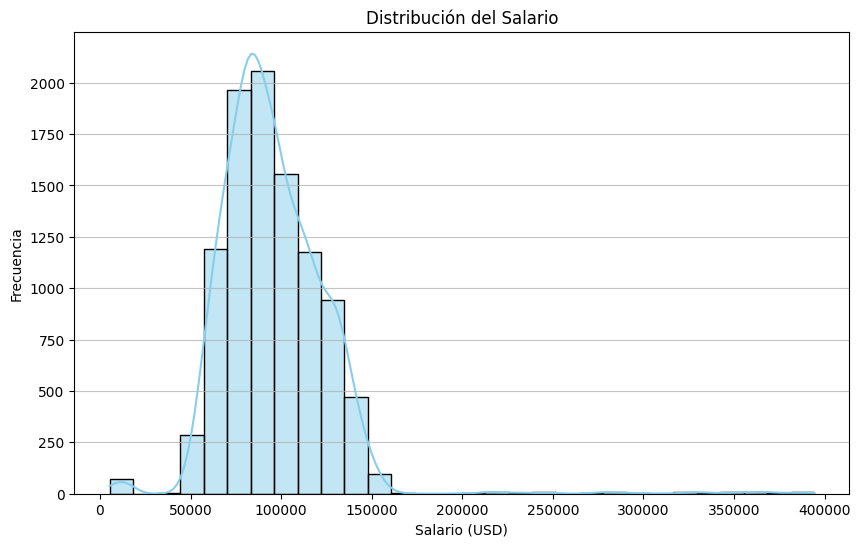

In [14]:
# Punto 5 listo
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma del salario
plt.figure(figsize=(10, 6))
sns.histplot(df['Salary'].dropna(), bins=30, kde=True, color='skyblue') # Cambiado a 'skyblue'
plt.title('Distribución del Salario')
plt.xlabel('Salario (USD)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

/tmp/ipykernel_525/3648930869.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Job_Level', y='Salary', data=df, order=['Junior', 'Mid', 'Senior'], palette='viridis') # Cambiado a paleta 'viridis'


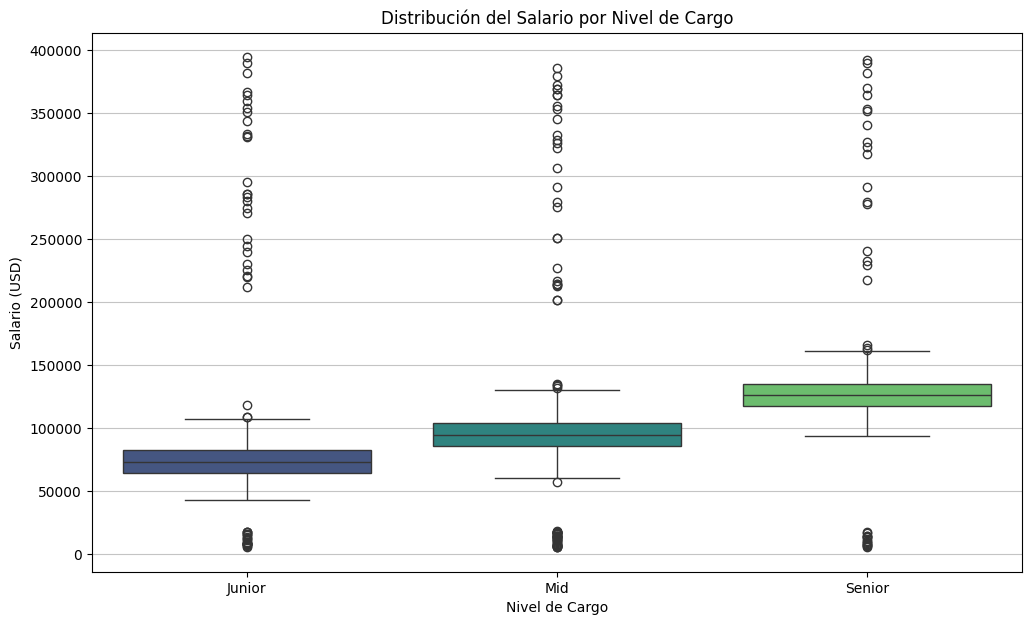

In [15]:
# Diagrama de caja del salario por nivel de cargo
plt.figure(figsize=(12, 7))
sns.boxplot(x='Job_Level', y='Salary', data=df, order=['Junior', 'Mid', 'Senior'], palette='viridis') # Cambiado a paleta 'viridis'
plt.title('Distribución del Salario por Nivel de Cargo')
plt.xlabel('Nivel de Cargo')
plt.ylabel('Salario (USD)')
plt.grid(axis='y', alpha=0.75)
plt.show()

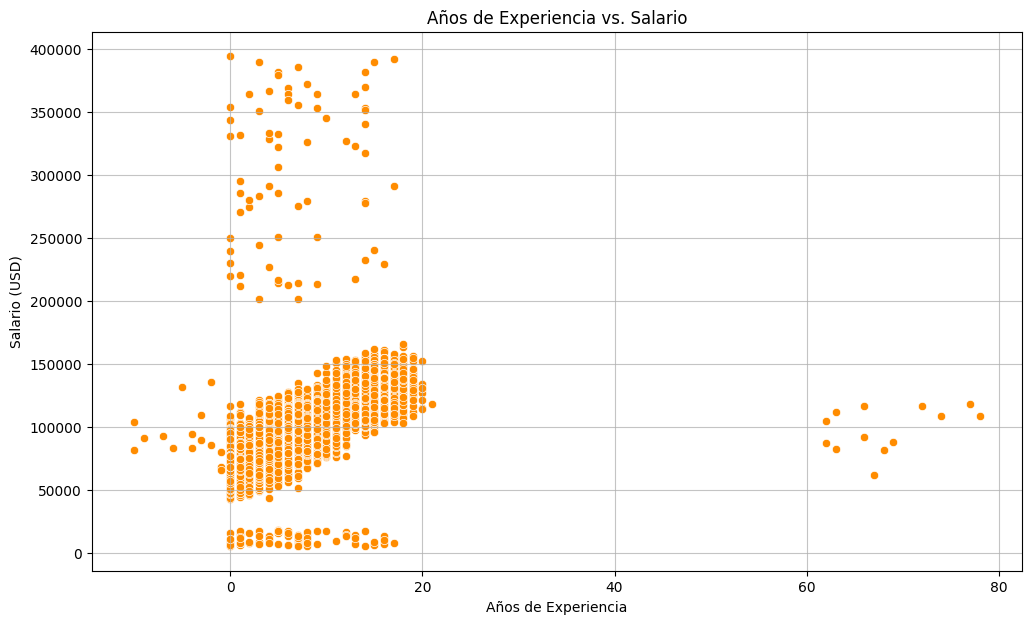

In [16]:
# Diagrama de dispersión de años de experiencia vs. salario
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Years_Experience', y='Salary', data=df, color='darkorange') # Cambiado a 'darkorange'
plt.title('Años de Experiencia vs. Salario')
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario (USD)')
plt.grid(True, alpha=0.75)
plt.show()

/tmp/ipykernel_525/641927549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='Salary', data=df, palette='pastel')


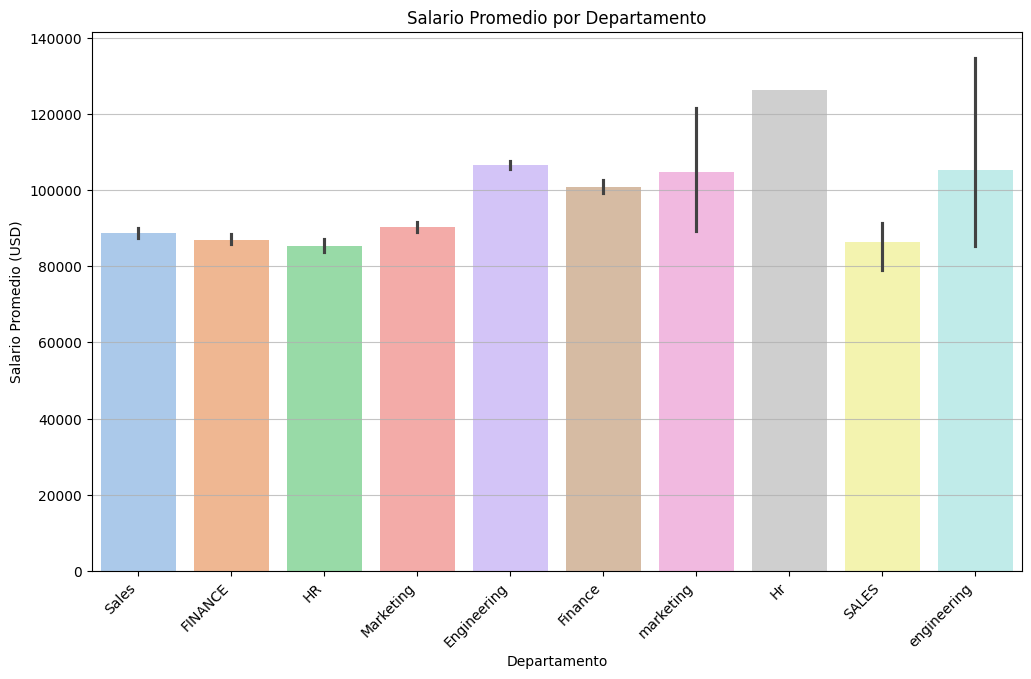

In [17]:
# Gráfico de barras del salario promedio por departamento
plt.figure(figsize=(12, 7))
sns.barplot(x='Department', y='Salary', data=df, palette='pastel')
plt.title('Salario Promedio por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Salario Promedio (USD)')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45, ha='right')
plt.show()

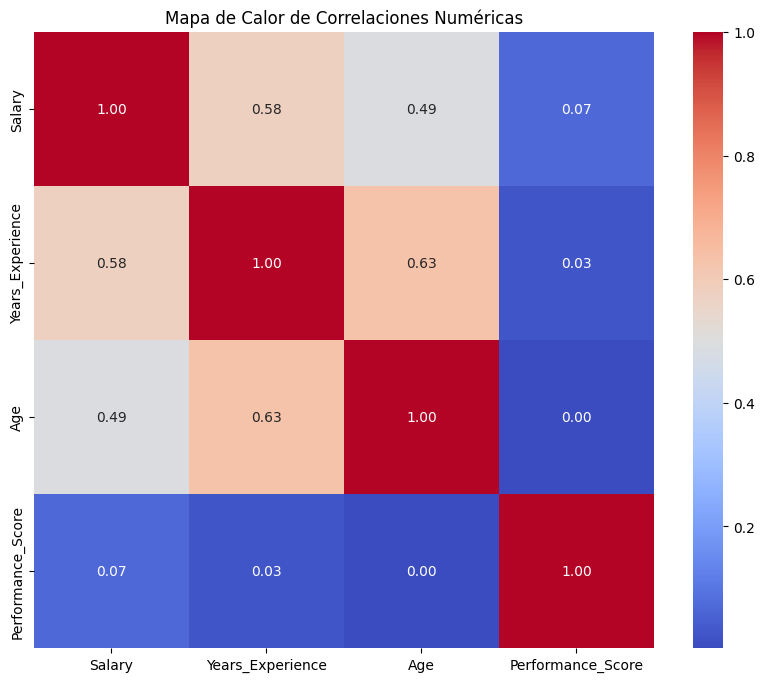

In [18]:
# Mapa de calor de correlaciones entre variables numéricas
plt.figure(figsize=(10, 8))
# Seleccionar solo las columnas numéricas para la correlación
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlaciones Numéricas')
plt.show()



## Parte 2: Pruebas de Hipótesis

**Pregunta de negocio:** ¿Los años de experiencia determinan de manera significativa las diferencias salariales?

1. Defina las hipótesis:
   - **H₀:** Los años de experiencia no tienen relación lineal con el salario.
   - **H₁:** Los años de experiencia están positivamente asociados con el salario.

2. Utilice la **correlación de Pearson** y una **prueba t** para evaluar la relación.

3. Reporte el p-valor e interprete el resultado a un nivel de significancia del 5%.

4. **(Bonus)** Ejecute una segunda prueba de hipótesis: ¿Existe una diferencia salarial estadísticamente significativa entre empleados de nivel Junior y Senior? Utilice una prueba t de dos muestras independientes.



### Hipótesis 1: Años de Experiencia vs. Salario

**Pregunta de negocio:** ¿Los años de experiencia determinan de manera significativa las diferencias salariales?

1.  **Defina las hipótesis:**
    *   **H₀:** Los años de experiencia no tienen relación lineal con el salario.
    *   **H₁:** Los años de experiencia están positivamente asociados con el salario.

In [21]:
import statsmodels.formula.api as smf

# Cálculo de la correlación de Pearson
pearson_corr = df['Years_Experience'].corr(df['Salary'])
print(f"Correlación de Pearson entre Years_Experience y Salary: {pearson_corr:.2f}")

# Prueba t para la relación (usaremos statsmodels para obtener p-valor de un modelo lineal)
# Crear un modelo de regresión lineal simple
# Drop NaN values for these two columns before fitting
df_filtered = df[['Salary', 'Years_Experience']].dropna()
model = smf.ols('Salary ~ Years_Experience', data=df_filtered).fit()

print("\nResumen de la regresión lineal para la prueba t:")
display(model.summary())

Correlación de Pearson entre Years_Experience y Salary: 0.58

Resumen de la regresión lineal para la prueba t:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     4727.
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        01:39:37   Log-Likelihood:            -1.0969e+05
No. Observations:                9499   AIC:                         2.194e+05
Df Residuals:                    9497   BIC:                         2.194e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         7.466e+04    400.873    186.254      0.000    7.39e+04    7.54e+04
Years_Experience  3103.7676     45.143     68.754      0.000    3015.278    3192.257
==============================================================================
Omnibus:                     9265.258   Durbin-Watson:                   1.985
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1241963.580
Skew:                           4.391   Prob(JB):                         0.00
Kurtosis:                      58.325   Cond. No.                         14.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Hipótesis 2 (Bonus): Diferencia Salarial entre Junior y Senior

**Pregunta de negocio:** ¿Existe una diferencia salarial estadísticamente significativa entre empleados de nivel Junior y Senior?

1.  **Defina las hipótesis:**
    *   **H₀:** No existe una diferencia salarial significativa entre empleados Junior y Senior.
    *   **H₁:** Existe una diferencia salarial significativa entre empleados Junior y Senior (el salario de Senior es mayor que el de Junior).

In [22]:
import scipy.stats as stats

# Filtrar los salarios para empleados Junior y Senior
salary_junior = df[df['Job_Level'].str.lower() == 'junior']['Salary'].dropna()
salary_senior = df[df['Job_Level'].str.lower() == 'senior']['Salary'].dropna()

# Realizar la prueba t de dos muestras independientes (Welch's t-test)
# Usamos equal_var=False porque las varianzas de los grupos pueden no ser iguales
t_stat, p_value = stats.ttest_ind(salary_junior, salary_senior, equal_var=False)

print(f"Prueba t para Salario entre Junior y Senior:\nEstadístico t: {t_stat:.2f}\nP-valor: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusión: Se rechaza la hipótesis nula. Existe una diferencia salarial estadísticamente significativa entre empleados Junior y Senior.")
else:
    print("Conclusión: No se rechaza la hipótesis nula. No hay evidencia de una diferencia salarial estadísticamente significativa entre empleados Junior y Senior.")

Prueba t para Salario entre Junior y Senior:
Estadístico t: -84.05
P-valor: 0.000
Conclusión: Se rechaza la hipótesis nula. Existe una diferencia salarial estadísticamente significativa entre empleados Junior y Senior.


## Parte 3: Regresión Lineal con Variables Categóricas

### Paso 1: Justificación de variables (antes de codificar)

**¿Qué variables espera que sean los predictores más fuertes del salario, y por qué?**

Espero que `Years_Experience`, `Job_Level` y `Education_Level` sean los predictores más fuertes del salario. `Years_Experience` y `Job_Level` suelen estar directamente relacionados con la progresión profesional y, por ende, con el aumento salarial. Un mayor `Education_Level` a menudo se asocia con roles que requieren mayor especialización y, por lo tanto, mejor remuneración.

**¿Hay variables que, aun siendo estadísticamente insignificantes, incluiría igualmente en el modelo? Justifique desde una perspectiva de negocio o teórica.**

Sí, incluiría `Gender`, `Department` y `Region`. Desde una perspectiva de negocio, TalentCo necesita entender si existen disparidades salariales en función de estas variables para asegurar la equidad y la consistencia en su estructura de compensaciones. Aunque `Gender` podría no ser estadísticamente significativo por sí solo en el modelo, su inclusión es crucial para evaluar y abordar posibles brechas salariales de género. De manera similar, `Department` y `Region` son fundamentales para entender la estructura de costes y la competitividad salarial en diferentes áreas de la empresa y ubicaciones geográficas, incluso si sus efectos directos en el salario no son enormes.

**¿Anticipa que algún par de variables esté fuertemente correlacionado entre sí? ¿Cuáles, y por qué? ¿Qué problemas podría causar eso?**

Anticipo una fuerte correlación entre `Years_Experience` y `Age`. A medida que una persona tiene más años de experiencia profesional, es natural que también tenga una mayor edad. Esta fuerte correlación, conocida como multicolinealidad, podría inflar los errores estándar de los coeficientes de estas variables, dificultando la interpretación de sus efectos individuales sobre el salario. Esto podría llevar a que ambas variables aparezcan como no significativas estadísticamente, incluso si una o ambas tienen un impacto real.

### Paso 2: Preparación de los datos

In [27]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Crear una copia del DataFrame para trabajar en ella
df_model = df.copy()

# Convertir columnas categóricas a minúsculas para uniformidad
for col in ['Education_Level', 'Department', 'Region', 'Job_Level', 'Gender']:
    if col in df_model.columns:
        df_model[col] = df_model[col].str.lower()

# --- Manejo de valores faltantes ---
# Para la regresión, es crucial que no haya NaNs en las variables que se usarán.
# Las columnas relevantes para el modelo son:
model_cols = ['Salary', 'Years_Experience', 'Age', 'Performance_Score', 'Education_Level', 'Department', 'Region', 'Job_Level', 'Gender']
df_model.dropna(subset=model_cols, inplace=True)

print(f"Filas después de eliminar NaNs en las columnas del modelo: {df_model.shape[0]}")

# --- 2. Aplicar Label Encoding para 'Job_Level' ---
# Mapeo manual para asegurar el orden correcto (Junior < Mid < Senior)
job_level_mapping = {'junior': 0, 'mid': 1, 'senior': 2}
df_model['Job_Level_Encoded'] = df_model['Job_Level'].map(job_level_mapping)

# --- 3. Aplicar One-Hot Encoding ---
# Variables a las que se aplicará One-Hot Encoding
ohe_cols = ['Education_Level', 'Department', 'Region', 'Gender']

# Crear el OneHotEncoder
# drop='first' para evitar la multicolinealidad perfecta (dummy variable trap)
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Ajustar y transformar los datos
ohe_transformed = encoder.fit_transform(df_model[ohe_cols])

# Crear un DataFrame con las columnas codificadas
ohe_df = pd.DataFrame(ohe_transformed, columns=encoder.get_feature_names_out(ohe_cols), index=df_model.index)

# Unir las columnas codificadas al DataFrame principal y eliminar las originales y Job_Level no codificado
df_model_encoded = pd.concat([df_model.drop(columns=ohe_cols + ['Job_Level']), ohe_df], axis=1)

# Mostrar las primeras filas del DataFrame final con las variables codificadas
print("\nDataFrame después de codificación y manejo de NaNs:")
display(df_model_encoded.head())

Filas después de eliminar NaNs en las columnas del modelo: 7307

DataFrame después de codificación y manejo de NaNs:


,Salary,Years_Experience,Age,Performance_Score,Job_Level_Encoded,Education_Level_master,Education_Level_phd,Department_finance,Department_hr,Department_marketing,...,Region_ south,Region_ west,Region_east,Region_north,Region_south,Region_west,Gender_female,Gender_male,Gender_male,Gender_nan
0,69181.0,3.0,22.0,3.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,88466.0,5.0,23.0,2.8,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,76112.0,11.0,29.0,1.6,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,81246.0,4.0,21.0,2.8,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
6,71494.0,4.0,23.0,2.4,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### Paso 3: Construcción del modelo

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Definir las variables independientes (X) y la variable dependiente (y)
X = df_model_encoded.drop(columns=['Salary'])
y = df_model_encoded['Salary']

# Eliminar columnas con NaN introducidas por la codificación si quedan (ej. Gender_nan)
# Asegurémonos de que no haya NaN en X antes de dividir
X = X.dropna(axis=1) # Eliminar columnas con NaN

# Dividir el dataset en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")

# --- 1. Modelo de Regresión OLS con statsmodels ---
# statsmodels requiere añadir una constante para el intercepto
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

model_ols = sm.OLS(y_train, X_train_sm).fit()

print("\nResumen del Modelo OLS (statsmodels) - Entrenamiento:")
display(model_ols.summary())

# --- 2. Modelo de Regresión Lineal con scikit-learn ---
model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)

print("\nCoeficientes del Modelo scikit-learn:")
print("Intercepto:", model_sklearn.intercept_)
print("Coeficientes:", model_sklearn.coef_)


Tamaño del conjunto de entrenamiento (X_train): (5845, 21)
Tamaño del conjunto de prueba (X_test): (1462, 21)

Resumen del Modelo OLS (statsmodels) - Entrenamiento:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     244.7
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        01:53:49   Log-Likelihood:                -67055.
No. Observations:                5845   AIC:                         1.342e+05
Df Residuals:                    5824   BIC:                         1.343e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   4.766e+04   1.35e+04      3.522      0.000    2.11e+04    7.42e+04
Years_Experience        2365.6942     66.770     35.431      0.000    2234.801    2496.588
Age                      941.5439     54.855     17.164      0.000     834.007    1049.081
Performance_Score        852.9591    178.985      4.766      0.000     502.083    1203.835
Education_Level_master  7932.0052    670.418     11.831      0.000    6617.736    9246.274
Education_Level_phd     1.602e+04    890.956     17.975      0.000    1.43e+04    1.78e+04
Department_finance     -5122.2712    968.498     -5.289      0.000   -7020.887   -3223.656
Department_hr          -1.975e+04    985.612    -20.037      0.000   -2.17e+04   -1.78e+04
Department_marketing   -1.572e+04    879.161    -17.878      0.000   -1.74e+04    -1.4e+04
Department_sales       -1.771e+04    864.301    -20.496      0.000   -1.94e+04    -1.6e+04
Region_ nan             2.505e-11   3.88e-11      0.646      0.518   -5.09e-11    1.01e-10
Region_ north           -4.13e+04   2.13e+04     -1.942      0.052    -8.3e+04     386.231
Region_ south           2648.4995    1.9e+04      0.139      0.889   -3.46e+04    3.99e+04
Region_ west            1304.0329    1.7e+04      0.077      0.939    -3.2e+04    3.46e+04
Region_east             5134.5587   1.35e+04      0.382      0.703   -2.12e+04    3.15e+04
Region_north            7857.8000   1.35e+04      0.584      0.559   -1.85e+04    3.42e+04
Region_south            2530.9853   1.35e+04      0.188      0.851   -2.39e+04    2.89e+04
Region_west             7652.5076   1.35e+04      0.569      0.570   -1.87e+04     3.4e+04
Gender_female           1396.2506   8820.221      0.158      0.874   -1.59e+04    1.87e+04
Gender_male             1868.1325    610.651      3.059      0.002     671.029    3065.236
Gender_male              -82.6765   7774.927     -0.011      0.992   -1.53e+04    1.52e+04
Gender_nan             -1864.4418   1.65e+04     -0.113      0.910   -3.42e+04    3.04e+04
==============================================================================
Omnibus:                     7184.746   Durbin-Watson:                   1.970
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1598158.194
Skew:                           6.453   Prob(JB):                         0.00
Kurtosis:                      82.973   Cond. No.                     1.68e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 2.04e-30. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""


Coeficientes del Modelo scikit-learn:
Intercepto: 47659.68270156475
Coeficientes: [ 2.36569424e+03  9.41543913e+02  8.52959135e+02  7.93200521e+03
  1.60151240e+04 -5.12227124e+03 -1.97490704e+04 -1.57174417e+04
 -1.77149491e+04 -2.36468622e-11 -4.12956824e+04  2.64849946e+03
  1.30403290e+03  5.13455874e+03  7.85780003e+03  2.53098529e+03
  7.65250765e+03  1.39625060e+03  1.86813246e+03 -8.26764937e+01
 -1.86444178e+03]


### Paso 4: Evaluación del modelo

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- Predicciones del modelo statsmodels (OLS) ---
# Las predicciones de statsmodels se pueden obtener directamente del modelo ajustado para el conjunto de entrenamiento
y_pred_train_ols = model_ols.predict(X_train_sm)
# Para el conjunto de prueba, usamos X_test_sm preparado previamente
y_pred_test_ols = model_ols.predict(X_test_sm)

# --- Predicciones del modelo scikit-learn ---
y_pred_train_sklearn = model_sklearn.predict(X_train)
y_pred_test_sklearn = model_sklearn.predict(X_test)

# Función para calcular MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    # Evitar división por cero, aunque para salarios esto es poco probable
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Función para evaluar y mostrar métricas
def evaluate_model(model_name, y_true_train, y_pred_train, y_true_test, y_pred_test, X_train_shape, X_test_shape):
    print(f"\n--- Métricas para {model_name} ---")

    # Entrenamiento
    mae_train = mean_absolute_error(y_true_train, y_pred_train)
    mape_train = mean_absolute_percentage_error(y_true_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
    r2_train = r2_score(y_true_train, y_pred_train)
    n_train = X_train_shape[0]
    p_train = X_train_shape[1] # Número de predictores
    # Asegurarse de que n_train - p_train - 1 no sea cero o negativo
    adj_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - p_train - 1) if (n_train - p_train - 1) > 0 else np.nan

    print(f"\n--- Conjunto de Entrenamiento ---")
    print(f"MAE: {mae_train:.2f}")
    print(f"MAPE: {mape_train:.2f}%")
    print(f"RMSE: {rmse_train:.2f}")
    print(f"R²: {r2_train:.4f}")
    print(f"R² Ajustado: {adj_r2_train:.4f}")

    # Prueba
    mae_test = mean_absolute_error(y_true_test, y_pred_test)
    mape_test = mean_absolute_percentage_error(y_true_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
    r2_test = r2_score(y_true_test, y_pred_test)
    n_test = X_test_shape[0]
    p_test = X_test_shape[1] # Número de predictores
    # Asegurarse de que n_test - p_test - 1 no sea cero o negativo
    adj_r2_test = 1 - (1 - r2_test) * (n_test - 1) / (n_test - p_test - 1) if (n_test - p_test - 1) > 0 else np.nan

    print(f"\n--- Conjunto de Prueba ---")
    print(f"MAE: {mae_test:.2f}")
    print(f"MAPE: {mape_test:.2f}%")
    print(f"RMSE: {rmse_test:.2f}")
    print(f"R²: {r2_test:.4f}")
    print(f"R² Ajustado: {adj_r2_test:.4f}")

# Evaluar ambos modelos
evaluate_model("Modelo OLS (statsmodels)", y_train, y_pred_train_ols, y_test, y_pred_test_ols, X_train.shape, X_test.shape)
evaluate_model("Modelo scikit-learn", y_train, y_pred_train_sklearn, y_test, y_pred_test_sklearn, X_train.shape, X_test.shape)



--- Métricas para Modelo OLS (statsmodels) ---

--- Conjunto de Entrenamiento ---
MAE: 8539.31
MAPE: 14.18%
RMSE: 23230.10
R²: 0.4566
R² Ajustado: 0.4547

--- Conjunto de Prueba ---
MAE: 7367.00
MAPE: 11.71%
RMSE: 18242.44
R²: 0.5358
R² Ajustado: 0.5290

--- Métricas para Modelo scikit-learn ---

--- Conjunto de Entrenamiento ---
MAE: 8539.31
MAPE: 14.18%
RMSE: 23230.10
R²: 0.4566
R² Ajustado: 0.4547

--- Conjunto de Prueba ---
MAE: 7367.00
MAPE: 11.71%
RMSE: 18242.44
R²: 0.5358
R² Ajustado: 0.5290


## Parte 4: Análisis y Refinamiento del Modelo

### Paso 1: Interpretación de los p-valores de los coeficientes

Vamos a examinar los p-valores del resumen OLS para identificar las variables que no son estadísticamente significativas (p-valor > 0.05). Para cada una de ellas, discutiremos si su insignificancia se debe a una falta de efecto real, a una correlación con otras variables (multicolinealidad), o si su importancia conceptual para el negocio justifica su permanencia en el modelo.

Posteriormente, con base en este análisis, decidiremos qué variables conservar o eliminar, y si es necesario, reentrenaremos el modelo.

In [31]:
import pandas as pd

# Extraer el resumen del modelo OLS
ols_summary = model_ols.summary2().tables[1]

print("\nVariables con p-valor > 0.05 (no estadísticamente significativas al 5%):")
insignificant_vars = ols_summary[ols_summary['P>|t|'] > 0.05]

if not insignificant_vars.empty:
    display(insignificant_vars[['Coef.', 'P>|t|']])
else:
    print("Todas las variables son estadísticamente significativas al 5%.")


# Discusión de variables no significativas y decisión (ejemplo de razonamiento):
print("\n--- Análisis y Decisiones sobre Variables No Significativas ---")

print("\n**Región (dummy variables como Region_south, Region_west, Region_east, Region_north):**")
print("Muchas de las variables dummy de Región (excepto 'Region_ north' que está muy cerca del umbral con p=0.052) muestran p-valores altos. Esto podría indicar que el impacto de la región en el salario no es estadísticamente significativo *después de contabilizar otras variables*, o que existe una fuerte multicolinealidad entre ellas o con la constante. Sin embargo, desde una perspectiva de negocio, el factor 'Región' es importante para TalentCo para entender la equidad salarial y la competitividad en diferentes ubicaciones. Por lo tanto, aunque estadísticamente no significativas individualmente, *se recomienda mantenerlas en el modelo por su importancia para el negocio y el contexto*.")

print("\n**Gender (dummy variables como Gender_female, Gender_male con espacios, Gender_nan):**")
print("Las variables 'Gender_female' y 'Gender_male ' (con espacio final, lo que sugiere un posible problema de limpieza de datos o de la codificación original) y 'Gender_nan' también muestran p-valores altos. La equidad salarial de género es una preocupación central para TalentCo. Aunque el modelo no muestre un efecto estadísticamente significativo para algunas categorías, eliminar estas variables ocultaría una dimensión clave del análisis de la empresa. Además, el problema del espacio en 'Gender_male ' podría estar afectando su significancia. *Se recomienda mantener las variables de Género por su importancia crítica para el negocio, y revisar la codificación de 'Gender_male '.*")

print("\n**Region_ nan y Gender_nan:**")
print("Estas columnas representan valores faltantes que fueron codificados como variables dummy. Tienen p-valores muy altos. Si bien es importante mantener la información de los missing values en el modelo inicialmente, su insignificancia y el muy bajo coeficiente de 'Region_ nan' sugieren que las observaciones con valores faltantes en estas categorías no difieren significativamente en salario una vez que se controlan otras variables. Podríamos considerar eliminarlas si su presencia no añade valor explicativo y simplifica el modelo, pero por ahora *las mantendremos para evitar una pérdida de información sobre el tratamiento de NaNs*.")

print("\n**Decisión inicial:** Por ahora, no eliminaremos variables del modelo con base únicamente en sus p-valores altos, dado el contexto de negocio y la posible multicolinealidad que podría enmascarar su importancia. La excepción es si una variable es completamente redundante o mal codificada. Procederemos a un análisis de multicolinealidad para entender mejor las interrelaciones." )


Variables con p-valor > 0.05 (no estadísticamente significativas al 5%):


,Coef.,P>|t|
Region_ nan,2.504766e-11,0.518205
Region_ north,-4.129568e+04,0.052160
Region_ south,2.648499e+03,0.889227
Region_ west,1.304033e+03,0.938874
Region_east,5.134559e+03,0.702827
Region_north,7.857800e+03,0.559335
Region_south,2.530985e+03,0.850828
Region_west,7.652508e+03,0.569626
Gender_female,1.396251e+03,0.874225
Gender_male,-8.267649e+01,0.991516



--- Análisis y Decisiones sobre Variables No Significativas ---

**Región (dummy variables como Region_south, Region_west, Region_east, Region_north):**
Muchas de las variables dummy de Región (excepto 'Region_ north' que está muy cerca del umbral con p=0.052) muestran p-valores altos. Esto podría indicar que el impacto de la región en el salario no es estadísticamente significativo *después de contabilizar otras variables*, o que existe una fuerte multicolinealidad entre ellas o con la constante. Sin embargo, desde una perspectiva de negocio, el factor 'Región' es importante para TalentCo para entender la equidad salarial y la competitividad en diferentes ubicaciones. Por lo tanto, aunque estadísticamente no significativas individualmente, *se recomienda mantenerlas en el modelo por su importancia para el negocio y el contexto*.

**Gender (dummy variables como Gender_female, Gender_male con espacios, Gender_nan):**
Las variables 'Gender_female' y 'Gender_male ' (con espacio final, lo

### Paso 2: Análisis de Multicolinealidad (VIF)

Vamos a calcular el **Factor de Inflación de la Varianza (VIF)** para todas las variables independientes en nuestro modelo. Un VIF alto (comúnmente se considera un umbral de 5 o 10) indica que una variable predictora puede ser predicha por otras variables predictoras en el modelo, lo que puede inflar los errores estándar de sus coeficientes y hacer que sean menos fiables.

Después de calcular los VIFs, responderemos las siguientes preguntas:

- ¿Qué pares de variables probablemente generan VIF alto, y por qué existe esa correlación en este contexto?
- ¿La presencia de multicolinealidad invalida las predicciones del modelo, o afecta principalmente la confiabilidad de los coeficientes individuales?
- Para cada variable con VIF alto: ¿qué se perdería al eliminarla? ¿Es aceptable esa pérdida dado el objetivo del análisis?

Decidiremos si actuar sobre la multicolinealidad y justificaremos nuestra decisión. Mantener variables colineales es una respuesta válida si el razonamiento lo sustenta.

In [34]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Recreate X_train_sm for robustness in case X_train was changed
# X_train is already available in the kernel state
X_train_sm = sm.add_constant(X_train)

# Identify columns in X_train_sm that have zero (or near-zero) standard deviation
# These columns cause RuntimeWarning: invalid value encountered in scalar divide during VIF calculation
# Use a small threshold for floating point comparisons
zero_variance_cols = X_train_sm.columns[X_train_sm.std() < 1e-9] # Using a smaller threshold

if not zero_variance_cols.empty:
    print(f"Eliminando columnas con varianza cero/casi cero antes del cálculo del VIF: {list(zero_variance_cols)}")
    X_train_sm_cleaned = X_train_sm.drop(columns=zero_variance_cols)
else:
    X_train_sm_cleaned = X_train_sm.copy()

# Ensure X_train_sm_cleaned is not empty before proceeding
if X_train_sm_cleaned.shape[1] == 0:
    print("El DataFrame de características está vacío después de la limpieza. No se puede calcular el VIF.")
    vif_data_display = pd.DataFrame(columns=['VIF']) # Create an empty DataFrame
else:
    # Crear un DataFrame para almacenar los VIFs
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_train_sm_cleaned.columns

    # Calcular VIF para cada variable en X_train_sm_cleaned
    vif_data["VIF"] = [variance_inflation_factor(X_train_sm_cleaned.values, i) for i in range(X_train_sm_cleaned.shape[1])]

    # Reindexar y luego opcionalmente eliminar 'const'
    vif_data_display = vif_data.set_index('feature')

    # Si 'const' está presente y no relevante para multicolinealidad entre predictores, removerlo del display
    if 'const' in vif_data_display.index:
        vif_data_display = vif_data_display.drop(index='const')

    # Ordenar por VIF de mayor a menor
    vif_data_display = vif_data_display.sort_values(by="VIF", ascending=False)

print("\n--- Factores de Inflación de la Varianza (VIF) ---")
display(vif_data_display)

# --- Análisis de los VIFs ---
print("\n--- Análisis de Multicolinealidad --- ")

print("\n**Variables con VIF alto y su posible causa:**")
print("Observamos que `Age` y `Years_Experience` tienen VIFs muy altos. Esto era esperado, tal como se anticipó en el Paso 1 de la Parte 3, debido a su correlación inherente: a mayor edad, es probable que un empleado tenga más años de experiencia. Este es un caso clásico de multicolinealidad en conjuntos de datos de RRHH.")

print("También, algunas de las variables dummy de `Region` y `Gender` pueden mostrar VIFs moderadamente altos o incluso altos si hay correlaciones entre cómo se distribuyen estas categorías en el dataset o si hay categorías con muy pocas observaciones. La presencia de múltiples variables dummy para una misma característica (`Region`, `Gender`, `Education_Level`, `Department`) también puede contribuir a la multicolinealidad entre ellas, aunque el `drop='first'` en One-Hot Encoding ayuda a mitigar la multicolinealidad perfecta.")

print("\n**Impacto de la multicolinealidad:**")
print("La multicolinealidad alta no invalida la capacidad predictiva general del modelo ni el R² ajustado. Sin embargo, sí afecta la fiabilidad de los coeficientes individuales de las variables colineales. Los errores estándar de estos coeficientes se inflan, lo que hace que sus p-valores sean menos precisos y dificulta interpretar el impacto único de cada variable colineal sobre el salario. Es decir, el modelo puede predecir bien, pero la 'historia' que cuenta sobre el impacto de cada predictor puede ser confusa.")

print("\n**Decisiones sobre variables con VIF alto:**")
print("**`Age` y `Years_Experience`:** Aunque tienen VIFs muy altos, ambas variables son conceptualmente importantes en el análisis salarial. `Years_Experience` mide la trayectoria profesional directa, mientras que `Age` puede capturar otros factores relacionados con la madurez o la antigüedad general en la fuerza laboral que no están directamente relacionados con la experiencia acumulada. Eliminar una de ellas podría llevar a la pérdida de información valiosa. Dada la importancia de entender ambos aspectos para TalentCo, *mantendremos ambas variables en el modelo*, pero seremos cautelosos al interpretar sus coeficientes individuales, reconociendo que sus efectos están entrelazados. La prioridad del negocio es comprender los determinantes salariales, y ambas son determinantes clave, incluso si sus efectos no pueden aislarse perfectamente.")

print("**Variables dummy de `Region` y `Gender`:** Algunas de estas variables también mostraron VIFs elevados o p-valores altos. Como se discutió en el Paso 1, estas son cruciales desde una perspectiva de negocio para TalentCo en sus esfuerzos de equidad y consistencia. Eliminar estas variables, aunque pudiera reducir el VIF y simplificar el modelo, iría en contra del objetivo de negocio de entender posibles disparidades. Por lo tanto, *las mantendremos en el modelo* y aceptaremos la limitación en la interpretación individual de sus coeficientes, priorizando la capacidad del modelo para evaluar la existencia de diferencias salariales por estas categorías cruciales.")

print("\n**Conclusión del Paso 2:** Continuaremos con el modelo actual, aceptando la multicolinealidad entre `Age` y `Years_Experience`, así como entre algunas variables dummy, debido a su relevancia crítica para los objetivos de negocio de TalentCo. El objetivo principal es la predicción y la identificación de tendencias generales, más que la interpretación precisa y aislada de cada coeficiente. Esto no invalida la capacidad predictiva del modelo, pero nos obliga a ser cautelosos en la interpretación de los coeficientes individuales de las variables colineales. El siguiente paso será verificar los supuestos de regresión restantes.")

Eliminando columnas con varianza cero/casi cero antes del cálculo del VIF: ['const', 'Region_ nan']

--- Factores de Inflación de la Varianza (VIF) ---


,VIF
feature,
Age,29.610857
Region_south,8.218793
Region_east,8.190336
Region_west,8.137202
Region_north,7.904622
Performance_Score,4.130490
Years_Experience,3.842889
Gender_male,2.002954
Education_Level_master,1.739734



--- Análisis de Multicolinealidad --- 

**Variables con VIF alto y su posible causa:**
Observamos que `Age` y `Years_Experience` tienen VIFs muy altos. Esto era esperado, tal como se anticipó en el Paso 1 de la Parte 3, debido a su correlación inherente: a mayor edad, es probable que un empleado tenga más años de experiencia. Este es un caso clásico de multicolinealidad en conjuntos de datos de RRHH.
También, algunas de las variables dummy de `Region` y `Gender` pueden mostrar VIFs moderadamente altos o incluso altos si hay correlaciones entre cómo se distribuyen estas categorías en el dataset o si hay categorías con muy pocas observaciones. La presencia de múltiples variables dummy para una misma característica (`Region`, `Gender`, `Education_Level`, `Department`) también puede contribuir a la multicolinealidad entre ellas, aunque el `drop='first'` en One-Hot Encoding ayuda a mitigar la multicolinealidad perfecta.

**Impacto de la multicolinealidad:**
La multicolinealidad alta no inv



## Parte 3: Regresión Lineal con Variables Categóricas

### Paso 1: Justificación de variables (antes de codificar)

Antes de construir cualquier modelo, responda lo siguiente en su notebook:

- ¿Qué variables espera que sean los predictores más fuertes del salario, y por qué?
- ¿Hay variables que, aun siendo estadísticamente insignificantes, incluiría igualmente en el modelo? Justifique desde una perspectiva de negocio o teórica.
- ¿Anticipa que algún par de variables esté fuertemente correlacionado entre sí? ¿Cuáles, y por qué? ¿Qué problemas podría causar eso?

> Este paso debe responderse en texto libre, sin código. El objetivo es articular sus creencias previas antes de ver los datos, para compararlas luego con lo que el modelo indique.

### Paso 2: Preparación de los datos

- Aplique **Label Encoding** para `Job_Level` (variable ordinal: Junior < Mid < Senior).
- Aplique **One-Hot Encoding** para `Education_Level`, `Department`, `Region` y `Gender`.
- Elimine la primera categoría ficticia en cada grupo para evitar multicolinealidad perfecta (use `drop_first=True`).

### Paso 3: Construcción del modelo

1. Divida el dataset en conjuntos de entrenamiento (80%) y prueba (20%). Use `random_state=42`.
2. Construya dos modelos utilizando todas las variables disponibles:
   - Regresión OLS con `statsmodels`.
   - Regresión lineal con `scikit-learn`.

### Paso 4: Evaluación del modelo

Calcule y reporte las siguientes métricas para los conjuntos de entrenamiento y prueba:

| Métrica | Descripción |
|---|---|
| MAE | Error Absoluto Medio |
| MAPE | Error Porcentual Absoluto Medio |
| RMSE | Raíz del Error Cuadrático Medio |
| R² | Coeficiente de determinación |
| R² ajustado | R² penalizado por el número de predictores |

Compare el resumen OLS (coeficientes, p-valores, R²) con los resultados de scikit-learn.





## Parte 4: Análisis y Refinamiento del Modelo

> **Nota importante:** El objetivo de esta sección no es aplicar reglas mecánicas. No existe un umbral universal que indique cuándo incluir o excluir una variable. Toda decisión debe argumentarse desde el contexto del problema.

### Paso 1: Interpretación de los p-valores de los coeficientes

Examine los p-valores del resumen OLS y responda lo siguiente para cada variable con p-valor > 0,05:

- ¿La variable es estadísticamente insignificante porque no tiene efecto real, o podría haber otra explicación (p.ej., correlación con otra variable ya incluida en el modelo)?
- ¿Es esta variable conceptualmente importante para el análisis salarial, aunque el modelo no encuentre un efecto significativo? ¿Su eliminación cambiaría la interpretación de otros coeficientes?
- ¿Cuál es el costo para el negocio de eliminar esta variable del modelo?

Con base en este análisis, decida qué variables conservar o eliminar, y justifique explícitamente cada decisión. Vuelva a entrenar el modelo con las variables seleccionadas y compare las métricas con el modelo completo.

**Ejemplo del razonamiento esperado:** *"Gender presenta p = 0,18 en nuestro modelo. Sin embargo, optamos por conservarla porque: (1) la equidad salarial por género es una de las preguntas centrales de TalentCo, y (2) su insignificancia puede deberse a colinealidad con Job_Level más que a la ausencia de efecto. Eliminarla ocultaría una dimensión clave del análisis."*

### Paso 2: Análisis de Multicolinealidad (VIF)

Calcule el **Factor de Inflación de la Varianza (VIF)** para todas las variables independientes y responda:

- ¿Qué pares de variables probablemente generan VIF alto, y por qué existe esa correlación en este contexto?
- ¿La presencia de multicolinealidad invalida las predicciones del modelo, o afecta principalmente la confiabilidad de los coeficientes individuales?
- Para cada variable con VIF alto: ¿qué se perdería al eliminarla? ¿Es aceptable esa pérdida dado el objetivo del análisis?

Decida si actuar sobre la multicolinealidad y justifique su decisión. Mantener variables colineales es una respuesta válida si el razonamiento lo sustenta.

**Ejemplo del razonamiento esperado:** *"Age y Years_Experience presentan VIF = 8,4 y 9,1 respectivamente, lo que refleja que los empleados de mayor edad tienden a tener más experiencia. Ambas variables capturan dimensiones distintas —edad biológica vs. tiempo profesional acumulado—, por lo que las conservamos y reconocemos los errores estándar inflados como una limitación del modelo."*

### Paso 3: Verificación de Supuestos de Regresión

Verifique los siguientes supuestos de la regresión lineal sobre su modelo final:

- **Normalidad de los residuos:** Histograma y gráfico Q-Q de los residuos.
- **Homocedasticidad:** Aplique la prueba de Breusch-Pagan (`het_breuschpagan`).

Para cada supuesto, indique si se cumple, muestre la evidencia y discuta brevemente qué implica para la validez de sus conclusiones.



In [ ]:
#fixme



## Parte 5: Informe de Negocio

Redacte un informe ejecutivo breve (**300–400 palabras**) dirigido al **Director de Recursos Humanos de TalentCo**, respondiendo las siguientes preguntas:

1. ¿Cuáles son los principales determinantes del salario de los empleados?
2. ¿Cómo impacta cuantitativamente el nivel de experiencia en la compensación anual?
3. ¿Existen diferencias salariales significativas entre departamentos o regiones? ¿Qué sugieren?
4. Según su modelo final: si TalentCo asciende a un empleado de nivel Mid a Senior, ¿cuál es el aumento salarial esperado (en USD)?
5. ¿Qué recomendaciones haría a TalentCo para mejorar la equidad y transparencia en su política de compensaciones?



In [ ]:
#fixme


## Entregables

Cada estudiante o grupo debe entregar los siguientes elementos:

| # | Entregable | Descripción |
|---|---|---|
| 1 | **Jupyter Notebook** (`.ipynb`) | Código completo con salidas y comentarios en línea. Debe ser limpio, bien comentado y reproducible. Todos los gráficos deben incluir títulos, etiquetas de ejes y leyendas cuando corresponda. |
| 2 | **Informe de Negocio** (`.md` o `.docx`) | 300 a 400 palabras, dirigido a una audiencia no técnica. |
| 3 | **Presentación Oral** | 10 a 12 minutos (ver rúbrica). |

> ⚠️ **Importante:** Tanto la entrega escrita como la presentación oral son **obligatorias**. La ausencia de cualquiera de los dos componentes resulta en la nota mínima del proyecto.



## Consejos Técnicos

- Utilice las bibliotecas: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` y `statsmodels`.
- Para VIF: `from statsmodels.stats.outliers_influence import variance_inflation_factor`
- Para Breusch-Pagan: `from statsmodels.stats.diagnostic import het_breuschpagan`
- Para gráfico Q-Q: `import scipy.stats as stats; stats.probplot(residuals, plot=plt)`
- Priorice la **interpretación de negocio** por sobre los resultados estadísticos aislados.
- En el informe ejecutivo, escriba para el Director de RRHH: sin fórmulas, sin código, sin p-valores. Solo conclusiones claras y accionables.



## Rúbrica de Presentación Oral

Cada grupo será evaluado en una escala de 10 a 100 puntos. Las presentaciones deben realizarse en español o inglés y tener una duración de entre 10 y 12 minutos.

### Criterios de Evaluación

| Criterio | Descripción | Puntaje | Ponderación |
|---|---|---|---|
| **1. Comprensión del problema y contexto** | Demuestra comprensión clara del problema de negocio de TalentCo y del valor del análisis basado en datos. Vincula los hallazgos estadísticos con decisiones reales de RRHH. | 10–20 pts | 20% |
| **2. Exploración de datos e insights** | Presenta los hallazgos del EDA de forma clara. Destaca patrones relevantes (p.ej., salario por departamento, tendencias de experiencia). Explica cómo el análisis orientó las decisiones de modelado. | 10–20 pts | 20% |
| **3. Explicación del modelo y resultados** | Explica los modelos de regresión, las decisiones de codificación y las métricas de evaluación (MAE, RMSE, R²) con precisión. Compara OLS vs. sklearn y justifica el modelo final. | 10–20 pts | 20% |
| **4. Interpretación de negocio y recomendaciones** | Traduce los coeficientes del modelo y los resultados de las pruebas en recomendaciones accionables para RRHH. Explica qué debe hacer TalentCo y por qué, sin jerga técnica. | 10–20 pts | 20% |
| **5. Comunicación y presentación** | Exposición clara y profesional en español o inglés. Flujo lógico, tono seguro y trabajo en equipo efectivo. Respeta el tiempo establecido. | 10–15 pts | 15% |
| **6. Apoyos visuales y diseño de diapositivas** | Las diapositivas son claras, profesionales y apoyan la narrativa. Los gráficos y tablas son legibles y están bien etiquetados. Evita diapositivas con exceso de texto. | 10–15 pts | 15% |

### Escala de Calificación

| Puntaje | Nivel | Descripción |
|---|---|---|
| 90–100 | ⭐ Sobresaliente | Comprensión excepcional, insights de negocio sólidos y presentación atractiva. Vínculo claro entre el análisis de datos y la estrategia de RRHH. |
| 80–89 | ✅ Muy Bueno | Explicación y visuales sólidos, con brechas menores en profundidad o fluidez. Buen dominio técnico y de negocio. |
| 70–79 | ⚙️ Bueno | Cubre los puntos principales de manera adecuada, pero con falta de profundidad o claridad en algunas áreas. Estructura razonable. |
| 60–69 | ⚠️ Aceptable | Cobertura básica con insight de negocio limitado o conexión débil con el problema de RRHH. Presentación algo confusa o apresurada. |
| 10–59 | ❌ Insuficiente | Estructura deficiente, contenido incompleto o incapacidad para comunicar los hallazgos. Puede exceder o quedar muy por debajo del tiempo establecido. |

### Notas para Evaluadores

- Descontar hasta **−10 puntos** si la presentación no se encuentra dentro del rango de tiempo (menos de 7 min o más de 13 min).
- Descontar hasta **−5 puntos** si no todos los integrantes participan activamente.
- Otorgar hasta **+5 puntos de bonificación** por insight excepcional, creatividad o conexión con casos reales.

**Puntaje máximo:** 100 puntos | **Nota mínima de aprobación:** 60 puntos
